# Group 4 — Modeling
**Europe Electricity Load Forecasting**  
Model: 37 Independent LightGBM Regressors (One per Country)  
Target: `Value` (hourly electricity load in MW)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Data

In [2]:
df = pd.read_csv('../data/engineered_data.csv', sep=';')

# Kosova (XK) verisi kronolojik olarak cok yetersiz (sadece 6 ay) oldugu icin projeden cikarildi
df = df[df['CountryCode'] != 'XK'].copy()

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (1044499, 17)
Columns: ['MeasureItem', 'DateUTC', 'DateShort', 'TimeFrom', 'TimeTo', 'CountryCode', 'Cov_ratio', 'Value', 'Value_ScaleTo100', 'year', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Load_Lag_1h', 'Load_Lag_24h', 'Rolling_Mean_24h']


,MeasureItem,DateUTC,DateShort,TimeFrom,TimeTo,CountryCode,Cov_ratio,Value,Value_ScaleTo100,year,Hour,DayOfWeek,Month,IsWeekend,Load_Lag_1h,Load_Lag_24h,Rolling_Mean_24h
0,Monthly Hourly Load Values,2019-01-02 00:00:00,2.01.2019,1.01.1970 00:00,1.01.1970 01:00,HU,100,3721.95,3721.95,2019,0,2,1,0,38392.625,3985.620,25029.456250
1,Monthly Hourly Load Values,2019-01-02 00:00:00,2.01.2019,1.01.1970 00:00,1.01.1970 01:00,FR,100,56993.00,56993.0,2019,0,2,1,0,59306.000,60301.000,57693.625000
2,Monthly Hourly Load Values,2019-01-02 00:00:00,2.01.2019,1.01.1970 00:00,1.01.1970 01:00,DE,100,42323.80,42323.8,2019,0,2,1,0,43827.015,416539.575,243379.148542
3,Monthly Hourly Load Values,2019-01-02 00:00:00,2.01.2019,1.01.1970 00:00,1.01.1970 01:00,SE,100,15938.00,15938.0,2019,0,2,1,0,16008.000,14375.000,16107.958333
4,Monthly Hourly Load Values,2019-01-02 00:00:00,2.01.2019,1.01.1970 00:00,1.01.1970 01:00,DK,100,2946.07,2946.07,2019,0,2,1,0,3028.110,3186.040,3508.647083


## 3. Remove Outliers & Fix Scaling Errors
Some countries have extreme outliers (e.g. BA, RO has typo MWs in Trillions) 
or scaling errors (e.g. DE, BE, HU, LU, NL have values erroneously multiplied by 10).

In [3]:
# Fix data inconsistencies in specific countries
# DE, BE, HU, LU, NL have some values erroneously multiplied by 10
df.loc[(df['CountryCode'] == 'DE') & (df['Value'] > 200000), 'Value'] /= 10
df.loc[(df['CountryCode'] == 'BE') & (df['Value'] > 30000), 'Value'] /= 10
df.loc[(df['CountryCode'] == 'HU') & (df['Value'] > 20000), 'Value'] /= 10
df.loc[(df['CountryCode'] == 'LU') & (df['Value'] > 2000), 'Value'] /= 10
df.loc[(df['CountryCode'] == 'NL') & (df['Value'] > 30000), 'Value'] /= 10

# Outlier Imputation for BA, RO (Typo in Trillions)
outlier_limits = {'BA': 5000, 'RO': 15000}
for c, limit in outlier_limits.items():
    idx = (df['CountryCode'] == c) & (df['Value'] > limit)
    df.loc[idx, 'Value'] = np.nan

# Aynı saat + ay kombinasyonunun ortalamasıyla doldur (Outlier Imputation)
df['Value'] = df.groupby(['CountryCode', 'Hour', 'Month'])['Value'].transform(
    lambda x: x.fillna(x.mean())
)
print(f"Kalan NaN: {df['Value'].isna().sum()}")

upper_limit = df['Value'].quantile(0.999)
print(f'Global upper limit (99.9th percentile): {upper_limit:,.2f}')

df = df[df['Value'] <= upper_limit].copy()
print(f'Shape after cleaning: {df.shape}')

Kalan NaN: 0
Global upper limit (99.9th percentile): 76,433.50
Shape after cleaning: (1043454, 17)


## 4. Define Features and Target
Instead of grouping countries, we will train independent models.

In [4]:
le = LabelEncoder()
df['CountryCode_encoded'] = le.fit_transform(df['CountryCode'])

df['Value_log'] = np.log1p(df['Value'])
df['DateUTC'] = pd.to_datetime(df['DateUTC'])
df['Year'] = df['DateUTC'].dt.year

FEATURES = ['Hour', 'DayOfWeek', 'Month', 'IsWeekend',
            'Load_Lag_1h', 'Load_Lag_24h', 'Rolling_Mean_24h',
            'CountryCode_encoded']

TARGET = 'Value_log'

print("Features defined.")

Features defined.


## 5. Train 37 Independent Models
Loop through each unique Country Code, split the data chronologically (70% Train, 15% Val, 15% Test), and train a specific LightGBM model for that country.

In [5]:
models = {}
results = {}

print(f"Training {len(df['CountryCode'].unique())} independent models (one for each country)... This will take a moment.\n")

for country in df['CountryCode'].unique():
    country_df = df[df['CountryCode'] == country].copy()
    country_df = country_df.sort_values('DateUTC')
    
    X_c = country_df[FEATURES]
    y_c = country_df[TARGET]
    
    n = len(country_df)
    if n < 500:  # Eğer bir ülkenin verisi çok çok azsa atla
        continue
        
    # Yıla göre hardcode bölmek yerine, her ülkenin kendi verisini %70, %15, %15 bölüyoruz
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)
    
    X_train_c, y_train_c = X_c.iloc[:train_end], y_c.iloc[:train_end]
    X_val_c, y_val_c = X_c.iloc[train_end:val_end], y_c.iloc[train_end:val_end]
    X_test_c, y_test_c = X_c.iloc[val_end:], y_c.iloc[val_end:]
    
    model_c = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=64,
        random_state=42,
        device='gpu',
        n_jobs=-1,
        verbose=-1
    )
    
    model_c.fit(
        X_train_c, y_train_c,
        eval_set=[(X_val_c, y_val_c)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    
    # Predict and inverse log transform to calculate actual MW errors
    y_pred_c = model_c.predict(X_test_c)
    y_pred_c_exp = np.expm1(y_pred_c)
    y_test_c_exp = np.expm1(y_test_c)
    
    models[country] = model_c
    results[country] = {
        'MAE': mean_absolute_error(y_test_c_exp, y_pred_c_exp),
        'RMSE': np.sqrt(mean_squared_error(y_test_c_exp, y_pred_c_exp)),
        'R2': r2_score(y_test_c_exp, y_pred_c_exp)
    }

results_df = pd.DataFrame(results).T
print(results_df.sort_values('R2', ascending=False).to_string())
print(f'\nToplam Eğitilen Model Sayısı: {len(models)}')
print(f'Overall Mean R² across all models: {results_df["R2"].mean():.4f}')

Training 37 independent models (one for each country)... This will take a moment.

            MAE         RMSE        R2
IT   292.709115   415.232208  0.996560
LU     4.619564     6.166497  0.995981
SE   164.891507   214.760457  0.995912
CZ    56.155371    78.847785  0.995868
AT    65.619245    87.888440  0.994950
PT    48.399886    69.228378  0.994806
HR    20.518735    28.405610  0.994802
FR   421.105702   627.553173  0.994733
FI    62.546805    83.061112  0.994427
PL   171.919911   244.583704  0.994179
LV     8.331742    12.548743  0.993895
DE   509.186275   684.879853  0.993856
NO   135.793899   253.931709  0.992912
UA   172.104246   227.537791  0.992511
ES   272.840031   372.769697  0.992240
SK    27.786326    40.096188  0.991857
LT    16.156736    26.021025  0.990970
BG    45.189227    67.692585  0.990270
GR    67.586793   110.145908  0.989931
MK    14.089502    19.356437  0.989823
SI    22.782363    29.851155  0.989399
IE    42.289776    65.839791  0.989313
DK    54.763388    7

## 6. Feature Importance (Example: Germany)

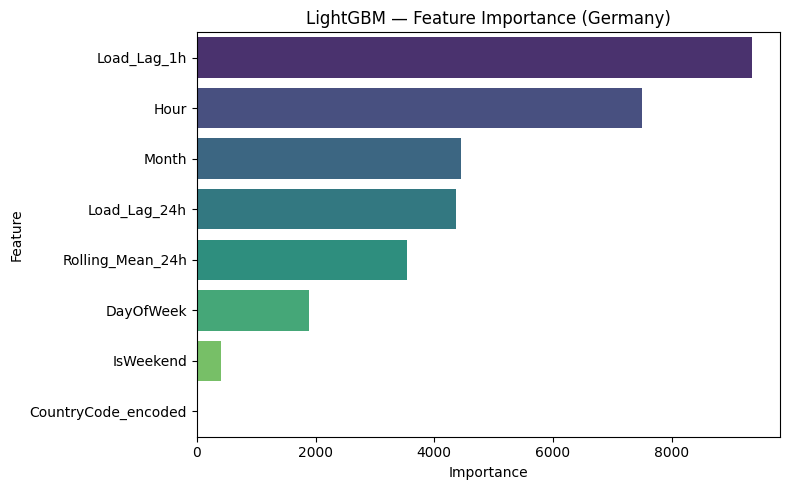

In [6]:
de_model = models.get('DE')
if de_model:
    importance_df = pd.DataFrame({
        'Feature': FEATURES,
        'Importance': de_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
    plt.title('LightGBM — Feature Importance (Germany)')
    plt.tight_layout()
    plt.savefig('../output/feature_importance_DE.png', dpi=150)
    plt.show()

## 7. Actual vs Predicted (Sample Plots)

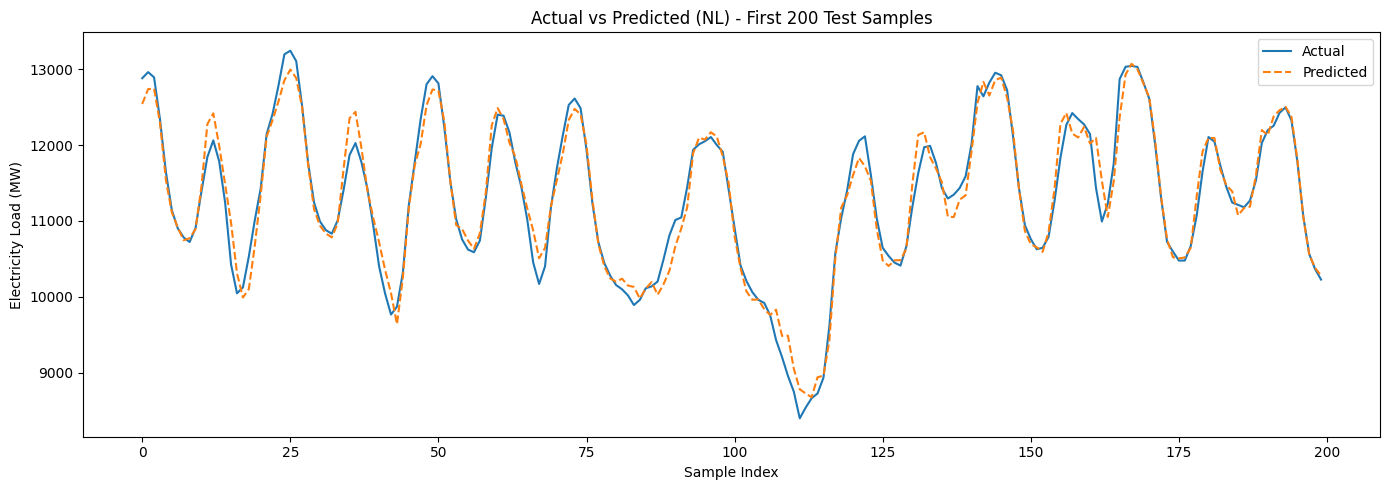

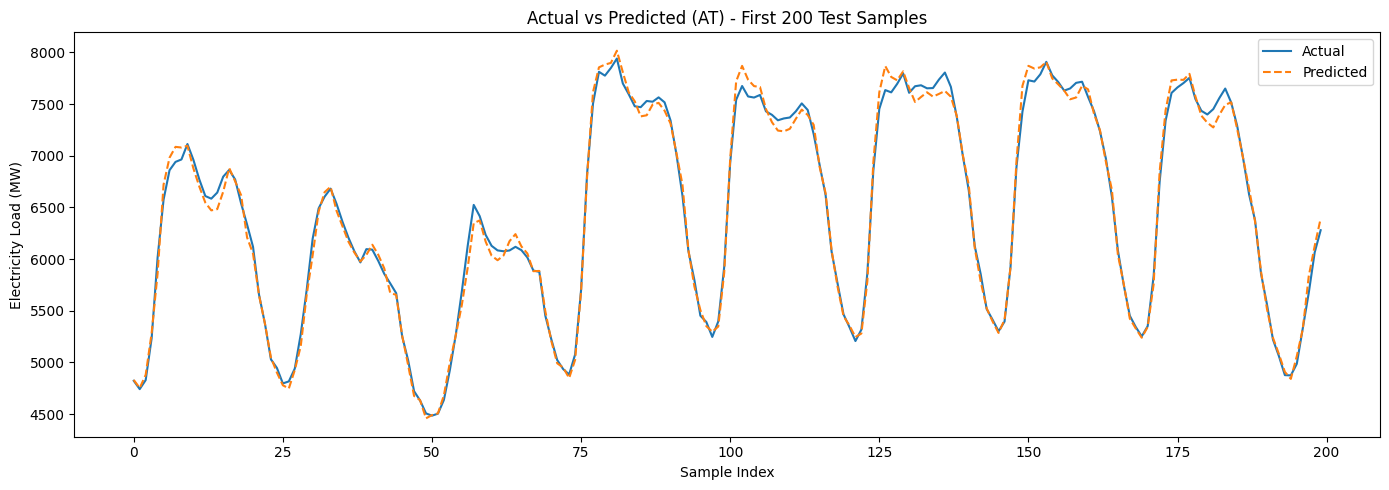

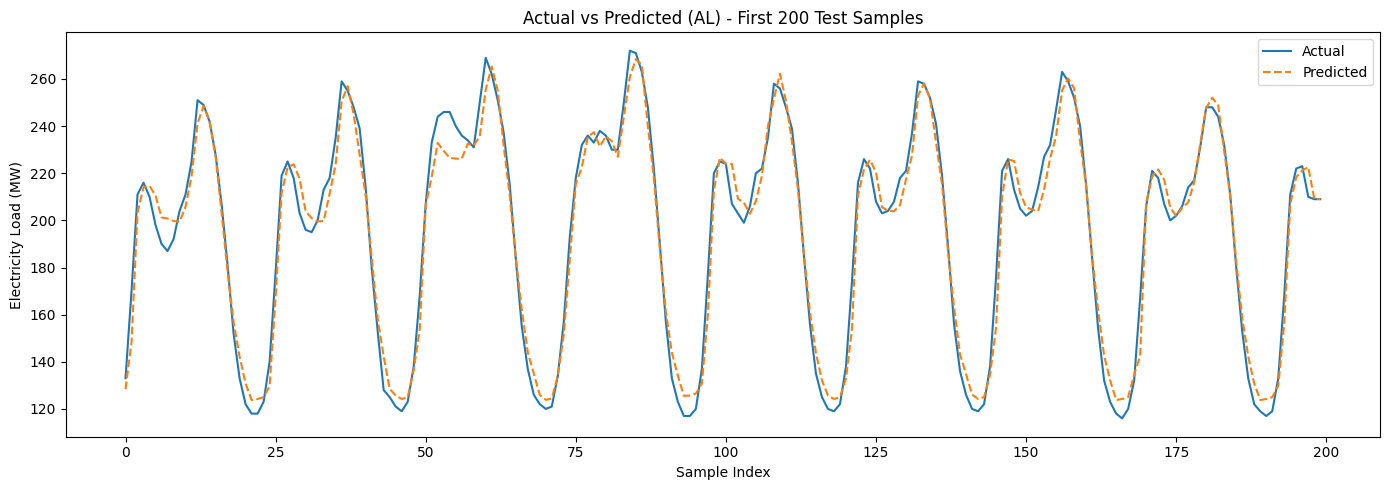

In [7]:
def plot_country_results(country_code):
    if country_code not in models:
        print(f"Model for {country_code} not found.")
        return
        
    country_df = df[df['CountryCode'] == country_code].copy()
    country_df = country_df.sort_values('DateUTC')
    
    n = len(country_df)
    val_end = int(n * 0.85)
    
    X_test_c = country_df.iloc[val_end:][FEATURES]
    y_test_c = country_df.iloc[val_end:][TARGET]
    
    if len(X_test_c) == 0:
        return
        
    y_pred_c = np.expm1(models[country_code].predict(X_test_c))
    y_test_c_exp = np.expm1(y_test_c)
    
    sample_size = 200
    y_t = y_test_c_exp.values[:sample_size]
    y_p = y_pred_c[:sample_size]
    
    plt.figure(figsize=(14, 5))
    plt.plot(y_t, label='Actual', linewidth=1.5)
    plt.plot(y_p, label='Predicted', linewidth=1.5, linestyle='--')
    plt.title(f'Actual vs Predicted ({country_code}) - First 200 Test Samples')
    plt.xlabel('Sample Index')
    plt.ylabel('Electricity Load (MW)')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Let's look at 3 very different scale countries
plot_country_results('NL')  # High Load
plot_country_results('AT')  # Medium Load
plot_country_results('AL')  # Low Load

## 8. Save Models to Disk
We save all 37 trained models to `../output/models/` for later use in our dashboard.

In [8]:
os.makedirs('../output/models', exist_ok=True)

for country, model in models.items():
    joblib.dump(model, f'../output/models/model_{country}.pkl')
    
print(f"{len(models)} model kaydedildi → ../output/models/")

37 model kaydedildi → ../output/models/
